# 査読コメント対応 — 実現距離 R(x*) と Z(x*) のトレードオフ

水谷先生経由で回ってきた Jinwoo 先生のコメント（2026-09-13、`reviwed/Optimal districting
for contract bundling_tracked changes_13sept_JL.docx` の冒頭）のうち、
**計算が必要な部分に答えるためのノートブック**。

原稿冒頭には3件のコメントが並んでいる。まず3件とも原文のまま引き、
それぞれに日本語の解釈を付す。そのうえで、このノートブックがどれに対応するかを述べる。

## Jinwoo 先生のコメント（原稿冒頭の3件）

### コメント1 — 契約集約と地理的広がりのパレートトレードオフを明示する

> It may be useful to characterize the Pareto tradeoff between contract consolidation
> and geographical extent more explicitly. Rather than only reporting the imposed
> distance limit $D$, the realized maximum within-area distance $R(x^*)$ could be
> recorded for each optimized solution. By varying $D$, the current constraint-based
> formulation can directly generate the nondominated relationship between $Z(x^*)$ and
> $R(x^*)$, without introducing the unit-dependent weight $\alpha$ in Eq. (17).
> Repeating this analysis for different bundling limits $L$, while holding $M$ fixed,
> could show how bundling capacity shifts the Pareto frontier between expected contract
> reduction and geographical management extent.

**日本語の解釈**

契約の集約と管理エリアの地理的な広がりのあいだのトレードオフを、もっとはっきり示せる
のではないか、という指摘。具体的には次の3つを言っている。

1. いま報告しているのは**課した**距離上限 $D$ だけである。それに加えて、各最適解が
   **実際に到達した**区域内最大距離 $R(x^*)$ も記録してはどうか。
2. $D$ を振れば、いまの制約型の定式化のままで $Z(x^*)$ と $R(x^*)$ の非劣関係
   （パレートフロンティア）が直接得られる。Eq. (17) の重み $\alpha$ ——
   件数と距離という単位の違うものを足すための係数 —— を持ち込まずに済む、という点が要。
3. さらに $M$ を固定したまま同時発注上限 $L$ を変えて同じことを繰り返せば、
   バンドリング能力がフロンティアをどう押し下げるかが見える。

3 は最適化を解き直す必要がある（第5章で所要時間を見積もる）。1・2 は保存済みの解から
計算できる。

### コメント2 — 経済的な解釈を任意で足せる

> An optional economic interpretation could be added without changing the optimization
> results. If each contract entails a common fixed procurement cost $F > 0$ and each
> repaired bridge incurs an additive cost $c \ge 0$ independent of districting, the
> expected annual cost is $F Z(x) + c\,q\,|I|$. Since $q\,|I|$ is fixed, minimizing this
> expression is equivalent to minimizing $Z(x)$. This interpretation concerns fixed
> procurement/administrative costs; it does not establish construction-cost economies of
> scale. Given the manuscript's clearly stated focus on contract-consolidation
> opportunities, a short interpretive remark may be sufficient, and changing the main
> objective is not essential.

**日本語の解釈**

契約1件あたりに共通の固定調達費 $F$ がかかり、補修する橋1橋あたりに地域分割に依らない
費用 $c$ がかかるとすると、期待年間費用は $F Z(x) + c\,q\,|I|$ と書ける。
本研究のモデルでは $q$ は全橋共通、$|I|$ は対象322橋で固定なので、第2項は地域分割に
依らない定数である。したがって**期待費用の最小化は $Z(x)$ の最小化と厳密に等価**になる。

ただしこれは固定的な調達費・管理費の話であって、工事費のスケールメリットを示したことには
ならない —— と Jinwoo 先生自身が釘を刺している。そのうえで「本文が契約集約の機会に
焦点を絞ると明言している以上、短い解釈の一文で足りるだろう。主目的関数を変える必要はない」
と結んでいる。

**計算は一切不要で、本文に2〜3文足すだけの対応になる。**

### コメント3 — 調達の信頼性（分散・チャンス制約）

> Although the current model uses the full stochastic repair-demand distribution, the
> objective considers only the expected number of contracts. To represent procurement
> reliability, let $Y(x)$ denote the realized total number of repair contracts required
> in a year, so that $Z(x) = \mathrm{E}[Y(x)]$. One option is to consider the variability
> of $Y(x)$. A more operational alternative is to impose a chance constraint such as
> $\Pr\{Y(x) > B\} \le \varepsilon$, where $B$ is the agency's annual
> contract-management capacity and $\varepsilon$ is the acceptable probability of
> exceeding that capacity. Otherwise, $\Pr\{W(x) > B_W\} \le \varepsilon$, where $W(x)$
> is the workload-based measure, e.g., $= a(\#\text{contracts}) + b(\#\text{bridge
> repaired})$, and $B_W$ is the workload-based capacity. This would allow the model to
> consider both expected procurement burden and the reliability of staying within
> procurement capacity, and could change the optimal districting itself. In my opinion,
> this extension should be left for future work at this point.

**日本語の解釈**

補修需要の確率分布そのものは使っているのに、目的関数は期待契約件数しか見ていない、
という指摘。実現する年間契約件数を $Y(x)$ と置けば $Z(x) = \mathrm{E}[Y(x)]$ であり、
いま使っているのはその期待値だけである。

そこで**調達の信頼性**を表すなら、$Y(x)$ のばらつきを見るか、より実務的には
「管理できる年間契約件数 $B$ を超える確率を $\varepsilon$ 以下に抑える」という
チャンス制約 $\Pr\{Y(x) > B\} \le \varepsilon$ を入れる手がある。
契約件数ではなく、契約件数と補修橋数の重み付き和という業務量 $W(x)$ で見る版も示されている。

これを入れると最適な地域分割そのものが変わりうる。ただし
**「現時点では今後の課題に回すべきだと思う」と Jinwoo 先生自身が明記している。**

## このノートブックが対応する範囲

上の3件のうち、**コメント1に対応する**。内訳は次のとおり。

| コメント | 対応 |
|---|---|
| **1（パレートトレードオフ）** | **このノートブックで計算する。** 前半（$R(x^*)$ の記録と $Z$–$R$ の非劣関係）は保存済みの解から求まり、再最適化は要らない。後半（$L$ を変えた掃引）は解き直しになるので、やるかどうかの判断材料として所要時間を第5章に出す |
| 2（経済的解釈） | 計算不要。本文に2〜3文を足す対応になるので、このノートブックの範囲外 |
| 3（チャンス制約） | Jinwoo 先生自身が今後の課題と明記。限界・今後の課題の段落に一文加える対応になるので、このノートブックの範囲外 |

### 中里さんからの確認ステップ

コメント1について、やってほしいこととして届いた内容をそのまま載せる。

> 要は「横軸を D（課した上限）ではなく、各解で実際に実現した区域内最大距離 R(x\*) にして、
> Z との関係を見せる」という話だと思います。
>
> 1. 36 ケースの割当 x\* が保存されているか確認．無ければ計算．
> 2. 各ケースで，区域ごとの橋梁間最大距離 R_k(x\*) と，その最大 R(x\*) を計算
>    （距離は MIP で使ったのと同じ大円距離の行列で）．全ケースで R(x\*) ≤ D に
>    なっているか確認．
> 3. 行は実行可能な (D, M) の36ケース＋現行区割り1行の計37行の表が欲しい．
>    列は D，M，Z(x\*)，R(x\*)，現行区割り比の削減率．
> 4. 横軸 R(x\*) [km]，縦軸 Z(x\*)．M ごとにマーカーを分けて，pareto frontier を
>    書く図が欲しい．FIG. 6 と差し替えるか併置かは水谷先生に決めてもらいましょう．
> 5. 1ケースの求解時間も教えてほしい．L を変えた掃引（Jinwoo 先生の提案の後半）を
>    やるかどうかの判断材料にします．

この5項目に、上から順に答えていく。

| | 確認ステップ | 回答セル |
|---|---|---|
| 1 | 36ケースの割当 x\* は保存されているか。無ければ計算する | 第1章 |
| 2 | 区域ごとの $R_k(x^*)$ と その最大 $R(x^*)$。全ケースで $R(x^*) \le D$ か | 第2章 |
| 3 | 36ケース＋現行区割り1行＝**37行**の表（D, M, Z, R, 削減率） | 第3章 |
| 4 | 横軸 $R(x^*)$、縦軸 $Z(x^*)$、M 別マーカー、パレートフロンティアの図 | 第4章 |
| 5 | 1ケースあたりの求解時間（L 掃引をやるかの判断材料） | 第5章 |

## 結論の先出し

- **再最適化は不要**。36ケースすべての割当行列が保存済みなので、$R(x^*)$ は距離行列を
  引くだけで求まる。Gurobi はこのノートブックでは使わない。
- $R(x^*)$ はほぼ全ケースで $D$ の直下に張り付く（制約が効いている）。したがって
  「$D$ を振って得たフロンティア」は実質 $R \approx D$ の対角線になる。これは Eq. (18) が
  **最適値を与える割当の中で $R$ を最小化していない**ことの裏返しで、
  Jinwoo 先生が本文中コメントで指摘している点と同じ。
- 副産物として、**$D = 15$ km の最適解は現行の行政区割りを両方の軸で下回る**
  （$R$: 16.33 → 14.95 km、$Z$: 2.588 → 2.087）。区域をむしろ狭めたまま契約を
  減らせる、という主張が1点で言える。

## 使い方

- **1セルずつ上から順に実行する**（「すべて実行」でも同じ）。セルは上から下へ
  一方向にしか依存しない。
- 計算そのものは `scripts/` 配下のプログラムが行い、このノートブックはそれを
  呼び出して結果を確かめるだけ。計算式はノートブック側に書かれていない。
- 各確認は `check(...)` が ✅ / ❌ を出し、最後の章で一覧表にまとめる。
- 出力先は既定では作業用フォルダ `outputs/reviewer_pareto/<実行時刻>/`。
  論文が参照する `figures/`・`outputs/` を更新したいときだけ、
  第0章の `UPDATE_CANONICAL` を `True` にする。

## 0. セットアップ

以降のすべてのセルが使う土台を用意する。`notebooks/pipeline_walkthrough.ipynb` と
同じ道具立て（`run` / `check` / `show`）をそのまま使う。

| 関数 | 役割 |
|---|---|
| `run(スクリプト名, 引数...)` | `scripts/` のプログラムを1本実行し、出力をそのまま表示する。失敗したら止まる |
| `check(章, 確認名, 真偽, 補足)` | 確認結果を1件記録して ✅ / ❌ を表示する |
| `show(画像パス)` | 生成された図をノートブック内に表示する |

In [1]:
from __future__ import annotations

import datetime
import os
import pickle
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display

# --- 1. リポジトリの位置を割り出す ------------------------------------------
# notebooks/ から開いてもリポジトリ直下から開いても同じように動くよう、
# scripts/ フォルダが見えるところまで1階層さかのぼる。
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "scripts").is_dir():
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / "scripts").is_dir(), f"リポジトリルートが見つからない: {Path.cwd()}"
sys.path.insert(0, str(REPO_ROOT / "src"))

# --- 2. この実行専用の出力フォルダを作る ------------------------------------
PY = sys.executable
RUN_ID = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
OUT = REPO_ROOT / "outputs" / "reviewer_pareto" / RUN_ID
OUT.mkdir(parents=True, exist_ok=True)

# --- 3. 図表の出力先を決める ------------------------------------------------
# 既定では作業用フォルダに出力し、論文が参照するファイルには触れない。
UPDATE_CANONICAL = False
FIG_DIR = (REPO_ROOT / "figures") if UPDATE_CANONICAL else OUT
TAB_DIR = (REPO_ROOT / "outputs") if UPDATE_CANONICAL else OUT
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

# --- 4. 以降のセルが使う共通の道具 ------------------------------------------
CHECKS: list[dict] = []


def check(stage: str, name: str, passed: bool, detail: str = "") -> bool:
    """確認結果を1件記録して ✅ / ❌ を表示する。"""
    CHECKS.append({"stage": stage, "check": name, "result": "PASS" if passed else "FAIL",
                   "detail": detail})
    print(f"{'✅' if passed else '❌'} [{stage}] {name}" + (f" — {detail}" if detail else ""))
    return passed


def run(script: str, *args, timeout: int = 1800) -> str:
    """scripts/ 配下のプログラムを1本実行し、その出力をそのまま表示する。"""
    cmd = [PY, str(REPO_ROOT / "scripts" / script), *map(str, args)]
    env = os.environ.copy()
    src = str(REPO_ROOT / "src")
    env["PYTHONPATH"] = src + (os.pathsep + env["PYTHONPATH"] if env.get("PYTHONPATH") else "")
    print(f"$ python scripts/{script} " + " ".join(map(str, args)))
    r = subprocess.run(cmd, cwd=REPO_ROOT, capture_output=True, text=True, env=env, timeout=timeout)
    print(r.stdout)
    if r.returncode != 0:
        print(r.stderr, file=sys.stderr)
        raise RuntimeError(f"{script} が終了コード {r.returncode} で失敗")
    return r.stdout


def show(path, width: int = 820) -> None:
    """生成された図をノートブック内に表示する。"""
    p = Path(path)
    display(Image(filename=str(p), width=width)) if p.exists() else print(f"(未生成: {p})")


# このノートブックが使う入力ファイル（すべてリポジトリに入っている）
SOLUTIONS_PKL = REPO_ROOT / "data/processed/districting_solutions_all36.pkl"
DISTANCE_PKL = REPO_ROOT / "data/processed/distance_matrix_322_20251208.pkl"
BRIDGES_CSV = REPO_ROOT / "data/processed/target_rc_bridges_322.csv"
RESULTS_CSV = REPO_ROOT / "data/processed/optimization_results_exact_objective.csv"

print("REPO_ROOT :", REPO_ROOT)
print("作業用出力:", OUT.relative_to(REPO_ROOT))
print("図の出力先:", FIG_DIR.relative_to(REPO_ROOT), "/ 表の出力先:", TAB_DIR.relative_to(REPO_ROOT))
print("UPDATE_CANONICAL =", UPDATE_CANONICAL, "（True なら figures/・outputs/ の正本を更新する）")

REPO_ROOT : /Users/fukuyamashunichi/research/paper-bundling-analysis
作業用出力: outputs/reviewer_pareto/20260919_175047
図の出力先: outputs/reviewer_pareto/20260919_175047 / 表の出力先: outputs/reviewer_pareto/20260919_175047
UPDATE_CANONICAL = False （True なら figures/・outputs/ の正本を更新する）


/Users/fukuyamashunichi/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## 1. 【確認ステップ1】36ケースの割当 x\* は保存されているか

**答え: 保存されている。再計算は不要。**

地域分割最適化を解く `scripts/run_gurobi_districting.py` は、結果CSVとは別に
`--solutions-output` で**割当行列そのもの**を pickle に書き出す。実行可能だった
36ケース分が `data/processed/districting_solutions_all36.pkl` に入っており、
これはリポジトリに含まれている（Git 管理下）。

pickle の中身は `(D, M) → {"assignment", "row", "order"}` の辞書で、

- `assignment` — 322×M の 0/1 行列。行が橋梁、列が管理エリア
- `order` — 行の並び順に対応する `shisetsu_id` のリスト。距離行列の `order` と同じ並び
- `row` — そのケースの結果CSV1行分（目的値・地域別橋梁数・求解時間など）

このセルでは、36ケース揃っていること、行列の形が正しいこと、
各橋梁がちょうど1エリアに割り当てられていること、そして
**正本の結果CSVと同じ (D, M) の集合であること**を確認する。

In [2]:
with SOLUTIONS_PKL.open("rb") as f:
    solutions = pickle.load(f)

results = pd.read_csv(RESULTS_CSV)
solved = results[results["Status"] == 2]

print(f"{SOLUTIONS_PKL.relative_to(REPO_ROOT)}")
print(f"  ケース数: {len(solutions)}")
print(f"  (D, M)  : {sorted(solutions.keys())}\n")

check("1.割当", "36ケース揃っている", len(solutions) == 36, f"{len(solutions)} ケース")

# 正本CSVの (D, M) 集合と一致するか。片方だけにあるケースがあれば図表がずれる。
keys_pkl = {(float(d), int(m)) for d, m in solutions.keys()}
keys_csv = {(float(r["MaxDistance"]), int(r["M"])) for _, r in solved.iterrows()}
check("1.割当", "正本CSVと同じ (D, M) の集合",
      keys_pkl == keys_csv,
      f"pklのみ={sorted(keys_pkl - keys_csv)} / CSVのみ={sorted(keys_csv - keys_pkl)}")

# 割当行列の形と、各橋梁がちょうど1エリアに入っていること
shape_ok, onehot_ok, order_ok = True, True, True
for (d, m), entry in solutions.items():
    a = np.asarray(entry["assignment"])
    shape_ok &= a.shape == (322, m)
    onehot_ok &= bool((a.sum(axis=1) == 1).all())
    order_ok &= len(entry["order"]) == 322

check("1.割当", "行列の形が 322×M", shape_ok)
check("1.割当", "各橋梁がちょうど1エリアに属する", onehot_ok)
check("1.割当", "order が 322 件", order_ok)

# 保存済みの結果行が、割当から再計算した地域別橋梁数と合うか（ここが崩れていたら
# pkl と CSV が別の実行のものということになる）
mismatch = []
for (d, m), entry in solutions.items():
    a = np.asarray(entry["assignment"])
    recomputed = sorted((int(a[:, k].sum()) for k in range(m)), reverse=True)
    stored = sorted((int(v) for v in str(entry["row"]["RegionCounts"]).split(";") if v), reverse=True)
    if recomputed != stored:
        mismatch.append((d, m))
_ = check("1.割当", "地域別橋梁数が保存行と一致", not mismatch, f"不一致 ={mismatch}")

data/processed/districting_solutions_all36.pkl
  ケース数: 36
  (D, M)  : [(15.0, 6), (20.0, 4), (20.0, 5), (20.0, 6), (25.0, 3), (25.0, 4), (25.0, 5), (25.0, 6), (30.0, 2), (30.0, 3), (30.0, 4), (30.0, 5), (30.0, 6), (35.0, 2), (35.0, 3), (35.0, 4), (35.0, 5), (35.0, 6), (40.0, 1), (40.0, 2), (40.0, 3), (40.0, 4), (40.0, 5), (40.0, 6), (45.0, 1), (45.0, 2), (45.0, 3), (45.0, 4), (45.0, 5), (45.0, 6), (50.0, 1), (50.0, 2), (50.0, 3), (50.0, 4), (50.0, 5), (50.0, 6)]

✅ [1.割当] 36ケース揃っている — 36 ケース
✅ [1.割当] 正本CSVと同じ (D, M) の集合 — pklのみ=[] / CSVのみ=[]
✅ [1.割当] 行列の形が 322×M
✅ [1.割当] 各橋梁がちょうど1エリアに属する
✅ [1.割当] order が 322 件
✅ [1.割当] 地域別橋梁数が保存行と一致 — 不一致 =[]


## 2. 【確認ステップ2】R_k(x\*) と R(x\*) を計算し、R(x\*) ≤ D を確認する

管理エリア k の**直径**（区域内で最も離れた2橋の距離）と、その全エリア最大を

$$R_k(x) = \max\{\, d_{ij} : i, j \in k \,\}, \qquad R(x) = \max_k R_k(x)$$

と定義する。橋梁が1つだけのエリアは $R_k = 0$ とする。

### 2-1. 距離が MIP で使ったものと同じ大円距離か確認する

R(x\*) は「最適化が実際に満たした制約の値」でなければ意味がないので、
**最適化に渡したのと同一の距離行列**を使う必要がある。
`data/processed/distance_matrix_322_20251208.pkl` がその行列で、
`run_gurobi_districting.py` が `--distance-matrix` として読むのもこれである。

中身が大円距離であることは、橋梁CSVの緯度経度から haversine 距離
（地球半径 6371.0088 km、`src/bundling_analysis/distance_cache.py`）を
計算し直して突き合わせれば確かめられる。

In [3]:
from bundling_analysis.distance_cache import haversine_km

with DISTANCE_PKL.open("rb") as f:
    dm = pickle.load(f)
order = [str(x) for x in dm["order"]]
D_MATRIX = np.asarray(dm["d_core"], dtype=float)

print(f"{DISTANCE_PKL.relative_to(REPO_ROOT)}")
print(f"  形: {D_MATRIX.shape}")
print(f"  最大距離（322橋全体の直径）: {D_MATRIX.max():.3f} km\n")

# 橋梁CSVの緯度経度から大円距離を計算し直して突き合わせる
bridges = pd.read_csv(BRIDGES_CSV)
b = bridges.assign(_sid=bridges["shisetsu_id"].astype(str)).set_index("_sid").loc[order]
lat = b["緯度"].to_numpy(float)
lon = b["経度"].to_numpy(float)
recomputed = haversine_km(lat[:, None], lon[:, None], lat[None, :], lon[None, :])

max_gap = float(np.abs(recomputed - D_MATRIX).max())
print(f"  再計算した haversine 距離との最大差: {max_gap:.3e} km")

check("2.距離", "距離行列が正方・対称", D_MATRIX.shape[0] == D_MATRIX.shape[1]
      and np.allclose(D_MATRIX, D_MATRIX.T))
check("2.距離", "対角が 0", bool(np.allclose(np.diag(D_MATRIX), 0.0)))
check("2.距離", "緯度経度からの大円距離と一致（< 1e-6 km）", max_gap < 1e-6,
      f"最大差 {max_gap:.3e} km")
_ = check("2.距離", "橋梁CSVと距離行列の shisetsu_id が同一集合",
          sorted(bridges["shisetsu_id"].astype(str)) == sorted(order))

data/processed/distance_matrix_322_20251208.pkl
  形: (322, 322)
  最大距離（322橋全体の直径）: 39.590 km

  再計算した haversine 距離との最大差: 7.105e-15 km
✅ [2.距離] 距離行列が正方・対称
✅ [2.距離] 対角が 0
✅ [2.距離] 緯度経度からの大円距離と一致（< 1e-6 km） — 最大差 7.105e-15 km
✅ [2.距離] 橋梁CSVと距離行列の shisetsu_id が同一集合


### 2-2. R_k(x\*)・R(x\*) を計算し、距離制約が守られているか確認する

計算は `scripts/compute_realized_radius.py` が行う。このプログラムは

1. 保存済み割当と距離行列から各エリアの直径 $R_k$ と全体の $R(x^*)$ を出す
2. 割当から地域別橋梁数と厳密目的値を計算し直し、**保存行と一致するか検証**する
3. **全ケースで $R(x^*) \le D$ か検証**する
4. 現行の行政区割り（橋梁を管理者でまとめたもの）を1行足して表にする

の順に動く。2 と 3 のどちらかが崩れたらエラーで止まる（`--no-verify` で無視可）。

In [4]:
RADIUS_CSV = TAB_DIR / "realized_radius.csv"

out = run("compute_realized_radius.py",
          "--solutions", SOLUTIONS_PKL,
          "--distance-matrix", DISTANCE_PKL,
          "--bridges", BRIDGES_CSV,
          "--bundle-limit", 5,
          "--output", RADIUS_CSV)

radius = pd.read_csv(RADIUS_CSV)
opt = radius[radius["Districting"] == "optimized"]

check("2.距離", "全36ケースで R(x*) <= D",
      bool((opt["RealizedRadius"] <= opt["MaxDistance"] + 1e-6).all()),
      f"R-D の最大は {float((opt['RealizedRadius'] - opt['MaxDistance']).max()):.6f} km（負なら制約内）")
check("2.距離", "検証がエラーなく完了（件数・目的値が保存行と一致）", "検証失敗" not in out)

# D に対して R がどれだけ余っているか。ほぼ 0 なら距離制約が効いている。
print("\nD ごとの余裕 D - R(x*) [km]:")
display(opt.groupby("MaxDistance")["Slack_D_minus_R"].agg(["min", "max"]).round(3))
print("→ D>=40 では 322 橋全体の直径 39.59 km に達し、制約が効かなくなる（余裕が開く）。")

$ python scripts/compute_realized_radius.py --solutions /Users/fukuyamashunichi/research/paper-bundling-analysis/data/processed/districting_solutions_all36.pkl --distance-matrix /Users/fukuyamashunichi/research/paper-bundling-analysis/data/processed/distance_matrix_322_20251208.pkl --bridges /Users/fukuyamashunichi/research/paper-bundling-analysis/data/processed/target_rc_bridges_322.csv --bundle-limit 5 --output /Users/fukuyamashunichi/research/paper-bundling-analysis/outputs/reviewer_pareto/20260919_175047/realized_radius.csv
q = 0.012329787974114258
current-management baseline (L=5) = 2.5883210709161215

検証1 保存行との一致 : 36/36 ケース
検証2 R(x*) <= D     : 36/36 ケース

非劣解 (Z(x*), R(x*)) — L=5 のもとで D と M を変えて得た 36 解の中での比較:
     D   M        Z*    R(x*)     削減率(%)      求解(s)
  15.0   6    2.0871    14.95       19.4     7603.1
  20.0   4    1.8219    19.99       29.6       60.2
  20.0   5    1.7912    19.99       30.8      254.2
  25.0   3    1.5677    24.99       39.4        2.5
  30.0   3    

,min,max
MaxDistance,,
15.0,0.055,0.055
20.0,0.008,0.009
25.0,0.008,0.008
30.0,0.069,0.219
35.0,0.123,0.163
40.0,0.410,0.410
45.0,5.410,5.410
50.0,10.410,10.410


→ D>=40 では 322 橋全体の直径 39.59 km に達し、制約が効かなくなる（余裕が開く）。


## 3. 【確認ステップ3】37行の表

行は **実行可能だった (D, M) の36ケース＋現行区割り1行**。
列は依頼どおり D・M・Z(x\*)・R(x\*)・現行区割り比の削減率で、
加えて求解時間と、非劣（パレート最適）かどうかの印を持たせてある。

現行区割りの行は、322橋をそれぞれの**管理者（市町）**でまとめたもので、
距離上限を課していないので D 欄は空にしてある。この行の Z が削減率の分母になる。

| 列 | 意味 |
|---|---|
| `Districting` | `optimized`（最適化した区割り）/ `current`（現行の行政区割り） |
| `MaxDistance` | 課した距離上限 D [km]。現行区割りには無い |
| `M` | 管理エリア数 |
| `ObjectiveValue_Exact` | Z(x\*) = 期待年間契約件数（閉形式による厳密値） |
| `RealizedRadius` | R(x\*) = 実現した区域内最大距離 [km] |
| `Slack_D_minus_R` | D − R(x\*)。0 に近いほど距離制約が効いている |
| `Reduction(%)` | 現行区割り比の削減率 |
| `ElapsedSeconds` | **Gurobi がそのケースを解くのに要した時間** [秒]。確認ステップ5がこれで、第5章で集計する |
| `Nondominated` | **パレート最適なら 1**。「$R(x^*)$ と $Z(x^*)$ の両方を同時に下回る解が他に1つも無い」という意味。0 のケースは、区域の広がりも契約件数も上回る解が他にあるので選ぶ理由が無い。**この判定は $L = 5$ のもとで $D$ と $M$ を変えて得た36解の中での比較**であって、問題本来のパレートフロンティアを指すものではない（下の 3-2 参照） |
| `RegionDiameters` | エリア別の $R_k$（大きい順） |
| `RegionCounts` | エリア別の橋梁数（大きい順） |

In [5]:
check("3.表", "37行（36ケース＋現行区割り1行）", len(radius) == 37, f"{len(radius)} 行")

# 依頼された5列を主役にした表示用の表
view = radius[["Districting", "MaxDistance", "M", "ObjectiveValue_Exact",
               "RealizedRadius", "Reduction(%)", "ElapsedSeconds", "Nondominated"]].copy()
view.columns = ["区割り", "D [km]", "M", "Z(x*)", "R(x*) [km]", "削減率 [%]",
                "求解時間 [s]", "パレート最適"]
view["Z(x*)"] = view["Z(x*)"].round(4)
view["R(x*) [km]"] = view["R(x*) [km]"].round(2)
view["削減率 [%]"] = view["削減率 [%]"].round(1)

display(view.style.hide(axis="index").format(na_rep="—"))
print(f"\n表の実体: {RADIUS_CSV}")

✅ [3.表] 37行（36ケース＋現行区割り1行） — 37 行


区割り,D [km],M,Z(x*),R(x*) [km],削減率 [%],求解時間 [s],パレート最適
optimized,15.000000,6,2.087100,14.950000,19.400000,7603.093000,1.000000
optimized,20.000000,4,1.821900,19.990000,29.600000,60.152000,1.000000
optimized,20.000000,5,1.791200,19.990000,30.800000,254.206000,1.000000
optimized,20.000000,6,1.791600,19.990000,30.800000,212.727000,0.000000
optimized,25.000000,3,1.567700,24.990000,39.400000,2.487000,1.000000
optimized,25.000000,4,1.569000,24.990000,39.400000,6.869000,0.000000
optimized,25.000000,5,1.570100,24.990000,39.300000,13.447000,0.000000
optimized,25.000000,6,1.571100,24.990000,39.300000,22.768000,0.000000
optimized,30.000000,2,1.634200,29.930000,36.900000,0.094000,0.000000
optimized,30.000000,3,1.416200,29.780000,45.300000,1.406000,1.000000



表の実体: /Users/fukuyamashunichi/research/paper-bundling-analysis/outputs/reviewer_pareto/20260919_175047/realized_radius.csv


### 3-2. パレート最適（非劣）な解だけを取り出す

「非劣（nondominated）」とは、**$R(x^*)$ と $Z(x^*)$ の両方を同時に下回る解が他に無い**
ということ。区域を広げずに契約も減らせる解が他にあるなら、そのケースを選ぶ理由は無いので、
比較の土俵に残るのはこの集合だけになる。

D を振って得られる (R, Z) の非劣集合。これが「D を振るだけで得られるフロンティア」で、
Eq. (17) の単位依存の重み α を持ち込まずに描ける、というのが Jinwoo 先生の趣旨。

現行区割りとの比較も、ここに並べれば一目で分かる。

#### 何に対して「非劣」なのか

ここでの判定は、**$L = 5$ のもとで $D$ と $M$ を変えて解いた36解の中での比較**である。
問題本来の連続なパレートフロンティアを求めたわけではない。論文・返信で使うときは、
この限定を落とさないこと。理由は2つある。

1. **格子点しか解いていない。** $D$ は 15〜50 km の5 km刻み、$M$ は 1〜6 だけで、
   その間の組合せは代表されていない。
2. **Eq. (18) は $R(x)$ を最小化していない。** 最適値 $Z(x^*)$ を与える割当は複数あり
   うるが、目的関数は $Z$ だけを見るので、ソルバが返す $R(x^*)$ はそのうちのどれか1つに
   過ぎない。**同じ $Z(x^*)$ でより小さい $R(x^*)$ を持つ解が存在しうる**が、
   この集合には現れない（4-2章と同じ話）。

図の凡例も同じ言い方に揃えて **"Nondominated among the 36 computed solutions"**
としてある。

In [6]:
frontier = radius[radius["Nondominated"] == 1].sort_values("RealizedRadius")
current = radius[radius["Districting"] == "current"].iloc[0]

print(f"現行の行政区割り: R = {current['RealizedRadius']:.2f} km, "
      f"Z = {current['ObjectiveValue_Exact']:.4f}（M = {int(current['M'])} 市町）\n")

front_view = frontier[["MaxDistance", "M", "ObjectiveValue_Exact", "RealizedRadius",
                       "Reduction(%)"]].copy()
front_view.columns = ["D [km]", "M", "Z(x*)", "R(x*) [km]", "削減率 [%]"]
display(front_view.round({"Z(x*)": 4, "R(x*) [km]": 2, "削減率 [%]": 1})
        .style.hide(axis="index"))

# 現行区割りを (R, Z) 両方で下回る解があるか。あれば「区域を広げずに契約を減らせる」と言える。
better = frontier[(frontier["RealizedRadius"] <= current["RealizedRadius"]) &
                  (frontier["ObjectiveValue_Exact"] <= current["ObjectiveValue_Exact"])]
_ = check("3.表", "現行区割りを (R, Z) 両方で下回る最適解が存在する", len(better) > 0,
          f"{len(better)} 件 — " + ", ".join(f"D={r['MaxDistance']:.0f}/M={int(r['M'])}"
                                             for _, r in better.iterrows()))

現行の行政区割り: R = 16.33 km, Z = 2.5883（M = 6 市町）



D [km],M,Z(x*),R(x*) [km],削減率 [%]
15.000000,6,2.087100,14.950000,19.400000
20.000000,4,1.821900,19.990000,29.600000
20.000000,5,1.791200,19.990000,30.800000
25.000000,3,1.567700,24.990000,39.400000
30.000000,3,1.416200,29.780000,45.300000
35.000000,2,1.346600,34.840000,48.000000
35.000000,3,1.262000,34.880000,51.200000
40.000000,1,1.193300,39.590000,53.900000
45.000000,1,1.193300,39.590000,53.900000
50.000000,1,1.193300,39.590000,53.900000


✅ [3.表] 現行区割りを (R, Z) 両方で下回る最適解が存在する — 1 件 — D=15/M=6


## 4. 【確認ステップ4】横軸 R(x\*)・縦軸 Z(x\*) の図

`scripts/plot_pareto_radius.py` が第3章の表から図を描く。

- マーカーは**管理エリア数 M 別に色と形の両方**を変える。$R(x^*)$ は同じ $D$ なら
  $M$ によらずほぼ同じ値に張り付くため、色だけでは重なった点を見分けられない
  （例: $D = 25$ の $M = 3$ と $M = 6$）。色の対応は `figures/dm_sensitivity`（現 FIG. 6）と
  共通の定義（`src/bundling_analysis/plotting_utils.py` の `M_COLORS` / `M_MARKERS`）を
  使うので、2つの図を並べても同じ $M$ が同じ色になる
- **非劣解は塗りつぶし＋濃い縁取りで、最後に描く**。劣解は小さめの白抜きにしてある。
  描画順を固定しているので、非劣解が他の点の下に隠れることはない
- 灰色の階段線が**パレートフロンティア**。点と点を直線で結ばないのは、
  フロンティアが点の集合であって連続曲線ではないため。階段は
  「区域内最大距離を R まで許したときに達成できる最小の Z」を表す
- 黒い星が**現行の行政区割り**
- `--annotate-d` を付けると、各フロンティア点にそれを生んだ D を添える

出力は PNG・SVG・PDF の3種類。本文用はベクタ（PDF）を使う。

**FIG. 6 と差し替えるか併置するかは水谷先生の判断待ち**なので、
既定では `figures/` を上書きせず作業用フォルダにだけ出す。
差し替えを決めたら第0章の `UPDATE_CANONICAL = True` で正本を更新できる。

$ python scripts/plot_pareto_radius.py --input /Users/fukuyamashunichi/research/paper-bundling-analysis/outputs/reviewer_pareto/20260919_175047/realized_radius.csv --annotate-d --output-stem /Users/fukuyamashunichi/research/paper-bundling-analysis/outputs/reviewer_pareto/20260919_175047/pareto_radius
Plotted points (R(x*), Z(x*)) by M:
  M=1, D=40.0: R= 39.590, Z=1.193327 *
  M=1, D=45.0: R= 39.590, Z=1.193327 *
  M=1, D=50.0: R= 39.590, Z=1.193327 *
  M=2, D=30.0: R= 29.931, Z=1.634245  
  M=2, D=35.0: R= 34.837, Z=1.346598 *
  M=2, D=40.0: R= 39.590, Z=1.203450  
  M=2, D=45.0: R= 39.590, Z=1.203450  
  M=2, D=50.0: R= 39.590, Z=1.203450  
  M=3, D=25.0: R= 24.992, Z=1.567653 *
  M=3, D=30.0: R= 29.781, Z=1.416189 *
  M=3, D=35.0: R= 34.877, Z=1.262041 *
  M=3, D=40.0: R= 39.590, Z=1.213577  
  M=3, D=45.0: R= 39.590, Z=1.213577  
  M=3, D=50.0: R= 39.590, Z=1.213577  
  M=4, D=20.0: R= 19.991, Z=1.821856 *
  M=4, D=25.0: R= 24.992, Z=1.568955  
  M=4, D=30.0: R= 29.781, Z=1.417214  

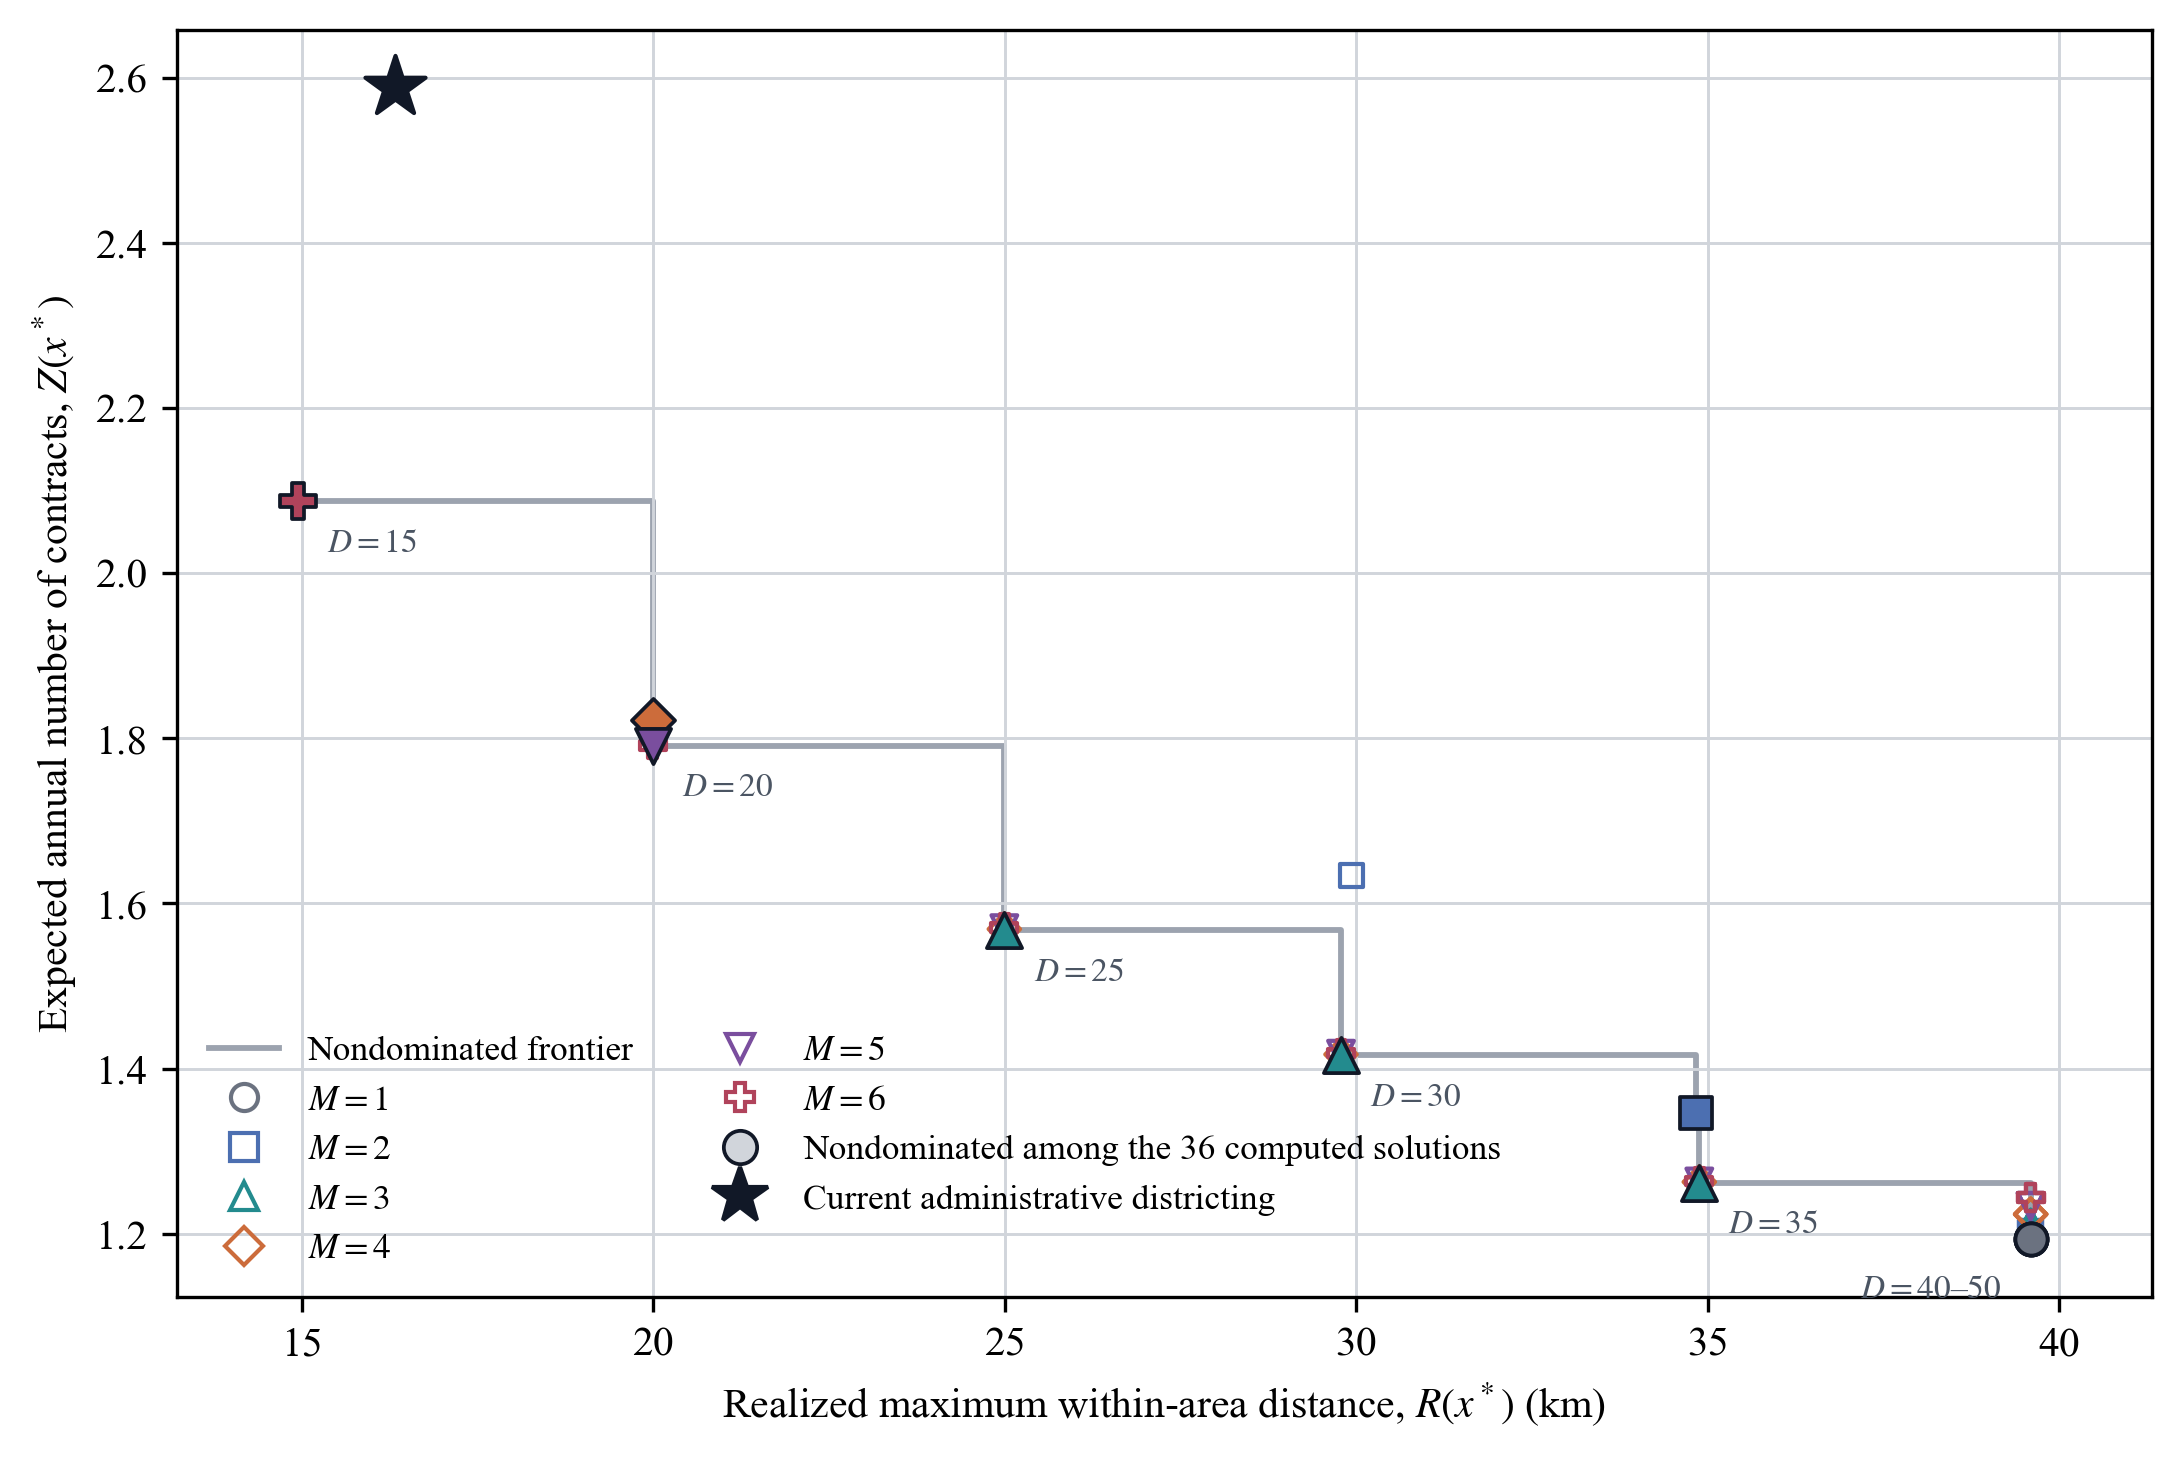

✅ [4.図] PNG が生成された — outputs/reviewer_pareto/20260919_175047/pareto_radius.png
✅ [4.図] SVG が生成された — outputs/reviewer_pareto/20260919_175047/pareto_radius.svg
✅ [4.図] PDF が生成された — outputs/reviewer_pareto/20260919_175047/pareto_radius.pdf


In [7]:
FIG_STEM = FIG_DIR / "pareto_radius"

run("plot_pareto_radius.py",
    "--input", RADIUS_CSV,
    "--annotate-d",
    "--output-stem", FIG_STEM)

show(FIG_STEM.with_suffix(".png"))

for ext in ("png", "svg", "pdf"):
    p = FIG_STEM.with_suffix(f".{ext}")
    check("4.図", f"{ext.upper()} が生成された", p.exists(), str(p.relative_to(REPO_ROOT)))

### 4-2. 参考: 現 FIG. 6（横軸 D）との対比

同じ36ケースを、横軸だけ D に戻したもの。**点の位置がほとんど変わらない**ことが、
「R(x\*) はほぼ D に張り付いている」ことの視覚的な確認になる。

裏を返すと、Eq. (18) は最適値を与える割当の中で R を最小化していないので、
この図の R はソルバが返した実現値であって、その Z を達成する**最小の**距離ではない。
本当に R が最小の非劣解が欲しければ、Z\* を固定して R を最小化する2段階
（辞書式）最適化が要り、そこは Gurobi での解き直しになる。

$ python scripts/plot_dm_sensitivity.py --input /Users/fukuyamashunichi/research/paper-bundling-analysis/data/processed/optimization_results_exact_objective.csv --bridges /Users/fukuyamashunichi/research/paper-bundling-analysis/data/processed/target_rc_bridges_322.csv --bundle-limit 5 --output-stem /Users/fukuyamashunichi/research/paper-bundling-analysis/outputs/reviewer_pareto/20260919_175047/dm_sensitivity_reference
q = 0.012329787974114258
current-management baseline = 2.588321070916122

Plotted points (D, M, ObjectiveValue_Exact):
  D=40.0, M=1: 1.193327
  D=45.0, M=1: 1.193327
  D=50.0, M=1: 1.193327
  D=30.0, M=2: 1.634245
  D=35.0, M=2: 1.346598
  D=40.0, M=2: 1.203450
  D=45.0, M=2: 1.203450
  D=50.0, M=2: 1.203450
  D=25.0, M=3: 1.567653
  D=30.0, M=3: 1.416189
  D=35.0, M=3: 1.262041
  D=40.0, M=3: 1.213577
  D=45.0, M=3: 1.213577
  D=50.0, M=3: 1.213577
  D=20.0, M=4: 1.821856
  D=25.0, M=4: 1.568955
  D=30.0, M=4: 1.417214
  D=35.0, M=4: 1.262783
  D=40.0, M=4: 1.223710
  D

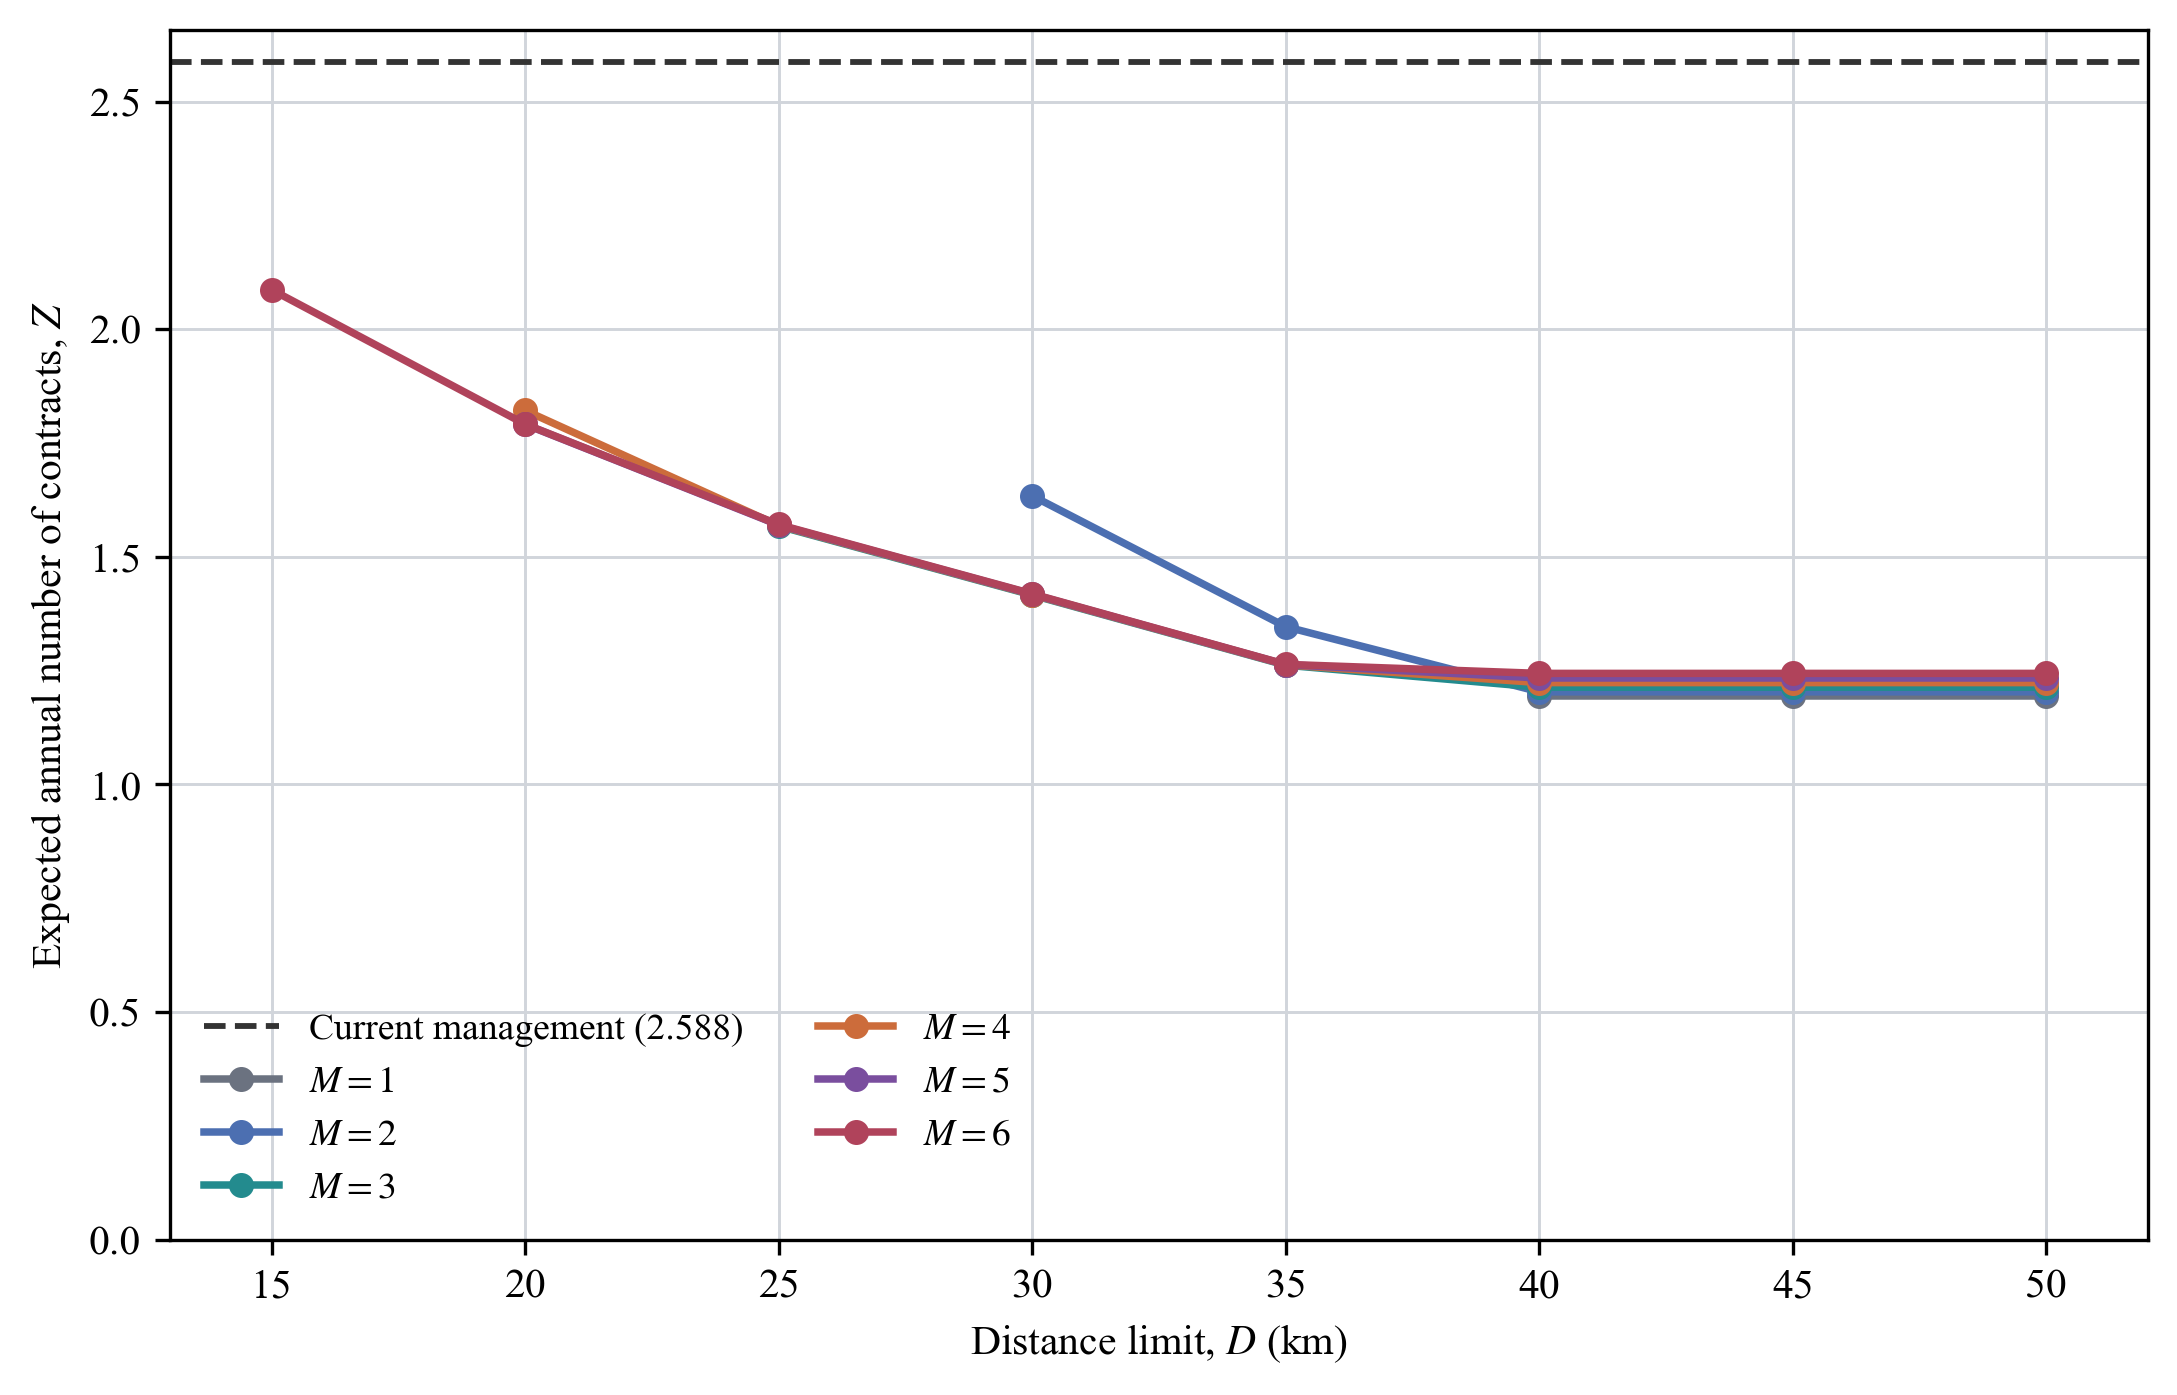

In [8]:
run("plot_dm_sensitivity.py",
    "--input", RESULTS_CSV,
    "--bridges", BRIDGES_CSV,
    "--bundle-limit", 5,
    "--output-stem", OUT / "dm_sensitivity_reference")

show(OUT / "dm_sensitivity_reference.png")

## 5. 【確認ステップ5】1ケースあたりの求解時間

L を変えた掃引（Jinwoo 先生の提案の後半、「M を固定して L を変え、
バンドリング能力がフロンティアをどう押し下げるか見る」）をやるかどうかの判断材料。

ここでいう求解時間とは、**Gurobi がそのケースの MIP を解き終えるまでにかかった時間**で、
結果CSVの `ElapsedSeconds` に入っている。全整数PWL・
`--warm-start-min-m 4 --mip-gap 0.005` での実測値である。

> **注記: `ElapsedSeconds` はウォームスタート用の事前計算を含まない。**
>
> `--warm-start-min-m 4` を付けた実行では、$M \ge 4$ のケースについて、
> 先に**20点PWL近似**で粗く解いた結果を MIP スタート（初期解）として本計算に渡している。
> `ElapsedSeconds` は本計算の `model.optimize()` だけを測っているので、
> **この事前計算の時間は含まれていない**。したがって $M \ge 4$ の
> 22ケースについては、表の値は実際に要した時間の**過小評価**である。
> $M \le 3$ の14ケースは事前計算を挟まないので、表の値がそのまま全所要時間になる。
>
> **$D = 15$ km・$M = 6$ の事前計算の時間は、残っている記録からは復元できなかった。**
> Gurobi のログは Windows 側の `outputs/`（gitignore 対象）にあってリポジトリに無く、
> スクリプトは事前解の目的関数値だけを表示して所要時間は出していなかった。
> 結果CSV・割当pkl にも本計算の行しか入っていない。
> 中里さんの「分からなければ再計算は不要」に従い、時間確認のための解き直しはしていない。
>
> 今後の実行（$L$ 掃引など）では復元できるよう、`run_gurobi_districting.py` に
> **`WarmStartSeconds`** と **`TotalSeconds`** の2列を追加した。
> 次に解き直したときからは、事前計算込みの所要時間がそのまま記録される。

**先に結論**: 費用はほぼ全部 M に乗っている。M ≤ 3 なら1ケース数秒で終わり、
M = 6・D = 15 の1ケースだけが2時間かかる。Jinwoo 先生の言う「M を固定して」
という枠組みは、固定する M 次第で所要時間が3桁変わる。

なお**実行可能な (D, M) の組は L に依存しない**（距離制約と「各エリアに1橋以上」
だけで決まる）ので、L を変えても同じ36ケースがそのまま使える。

In [9]:
times = results[results["Status"] == 2][["MaxDistance", "M", "ElapsedSeconds"]].copy()

print(f"全{len(times)}ケース合計: {times['ElapsedSeconds'].sum() / 3600:.2f} 時間")
print(f"中央値: {times['ElapsedSeconds'].median():.1f} 秒 / "
      f"最大: {times['ElapsedSeconds'].max():.0f} 秒\n")

# 実行時に使われた --warm-start-min-m。docs/multi_pc_git_python_notes.md 7-2章に
# 記録されている最終コマンド（--warm-start-min-m 4 --mip-gap 0.005）の値。
WARM_START_MIN_M = 4

by_m = times.groupby("M")["ElapsedSeconds"].agg(["count", "median", "max", "sum"])
by_m.columns = ["ケース数", "中央値 [s]", "最大 [s]", "合計 [s]"]
by_m["事前計算あり"] = ["あり（値は過小評価）" if m >= WARM_START_MIN_M else "なし"
                       for m in by_m.index]
display(by_m.round(1))

n_warm = int((times["M"] >= WARM_START_MIN_M).sum())
print(f"※ M>={WARM_START_MIN_M} の {n_warm} ケースは20点PWLの事前計算を挟んでおり、"
      f"その時間は ElapsedSeconds に含まれない（上の注記参照）。")
print(f"   残る {len(times) - n_warm} ケース（M<{WARM_START_MIN_M}）は事前計算なしなので、"
      f"値がそのまま全所要時間。")

# 今後の実行で事前計算の時間が記録されるようになったかを確認する。
has_warm_cols = {"WarmStartSeconds", "TotalSeconds"} <= set(results.columns)
print(f"\n結果CSVに WarmStartSeconds / TotalSeconds 列: "
      f"{'あり' if has_warm_cols else 'なし（この表は列の追加より前の実行のもの）'}")

print("\n所要時間の上位5ケース:")
top = times.nlargest(5, "ElapsedSeconds").copy()
top.columns = ["D [km]", "M", "求解時間 [s]"]
display(top.style.hide(axis="index").format({"求解時間 [s]": "{:.1f}"}))

# L 掃引の見積もり。実行可能な (D, M) は L に依らないので、同じケース集合を
# L 水準ごとに解き直すことになる。M を固定すればその M の行だけが効く。
print("\nL を1水準足したときの見積もり（同じケース集合を解き直す前提）:")
for m in sorted(times["M"].unique()):
    sub = times[times["M"] == m]
    d_range = f"D={sub['MaxDistance'].min():.0f}–{sub['MaxDistance'].max():.0f}"
    print(f"  M={m} 固定 ({len(sub)}ケース, {d_range}): {sub['ElapsedSeconds'].sum():>8.0f} 秒"
          f"  = {sub['ElapsedSeconds'].sum() / 3600:>5.2f} 時間")
print(f"  全36ケース             : {times['ElapsedSeconds'].sum():>8.0f} 秒"
      f"  = {times['ElapsedSeconds'].sum() / 3600:>5.2f} 時間")

全36ケース合計: 2.28 時間
中央値: 0.8 秒 / 最大: 7603 秒



,ケース数,中央値 [s],最大 [s],合計 [s],事前計算あり
M,,,,,
1,3,0.0,0.0,0.0,なし
2,5,0.1,0.1,0.4,なし
3,6,0.5,2.5,5.5,なし
4,7,1.3,60.2,76.6,あり（値は過小評価）
5,7,1.0,254.2,273.0,あり（値は過小評価）
6,8,2.3,7603.1,7844.6,あり（値は過小評価）


※ M>=4 の 22 ケースは20点PWLの事前計算を挟んでおり、その時間は ElapsedSeconds に含まれない（上の注記参照）。
   残る 14 ケース（M<4）は事前計算なしなので、値がそのまま全所要時間。

結果CSVに WarmStartSeconds / TotalSeconds 列: なし（この表は列の追加より前の実行のもの）

所要時間の上位5ケース:


D [km],M,求解時間 [s]
15.000000,6,7603.1
20.000000,5,254.2
20.000000,6,212.7
20.000000,4,60.2
25.000000,6,22.8



L を1水準足したときの見積もり（同じケース集合を解き直す前提）:
  M=1 固定 (3ケース, D=40–50):        0 秒  =  0.00 時間
  M=2 固定 (5ケース, D=30–50):        0 秒  =  0.00 時間
  M=3 固定 (6ケース, D=25–50):        5 秒  =  0.00 時間
  M=4 固定 (7ケース, D=20–50):       77 秒  =  0.02 時間
  M=5 固定 (7ケース, D=20–50):      273 秒  =  0.08 時間
  M=6 固定 (8ケース, D=15–50):     7845 秒  =  2.18 時間
  全36ケース             :     8200 秒  =  2.28 時間


### 5-2. L 掃引をやる場合のコマンド

`scripts/run_gurobi_districting.py` は `--bundle-limit` を既に持っているので、
**コードの改修は不要**。L 水準ごとに1回ずつ呼べばよい。
本文主結果の L = 5 は既存の36ケースをそのまま流用できるので、
新しく解くのは他の水準だけで済む。

Gurobi はこのマシンには入っていないので、ライセンスのある別PCで実行する
（`docs/remote_gurobi_setup.md`、`docs/multi_pc_git_python_notes.md`）。
長時間ジョブはセッション切断で2回落ちた実績があるため、
デタッチして走らせること（Windows ならタスクスケジューラ、Linux なら nohup / tmux）。

```bash
# 例: M=3 固定・D=25〜50（数秒で終わる）。L=2,3,10 を順に解く
for L in 2 3 10; do
  python scripts/run_gurobi_districting.py \
      --pwl all --bundle-limit $L \
      --cases 25:3 30:3 35:3 40:3 45:3 50:3 \
      --threads 8 --mip-gap 0.005 \
      --output outputs/lsweep_M3_L${L}.csv \
      --solutions-output outputs/lsweep_M3_L${L}_solutions.pkl
done
```

M = 6 に固定すれば D = 15〜50 の全域を1本の曲線にできる（対象6市町と同数という
解釈も付く）が、上の表のとおり1水準あたり約2.2時間かかる。

解き終わったら、その `--solutions-output` をこのノートブックの第2章に
そのまま渡せば、L 別の R(x\*) 表と図が同じ手順で作れる。

```python
run("compute_realized_radius.py",
    "--solutions", REPO_ROOT / "outputs/lsweep_M3_L3_solutions.pkl",
    "--bundle-limit", 3,                      # 削減率の分母も L=3 で計算し直される
    "--output", TAB_DIR / "realized_radius_L3.csv")
```

## 6. 確認の一覧

このノートブックで行った確認をまとめる。**すべて PASS であることが、
第3章の表と第4章の図を論文・返信に使える条件**である。

In [10]:
summary = pd.DataFrame(CHECKS)
display(summary.style.hide(axis="index"))

n_fail = int((summary["result"] == "FAIL").sum())
print(f"\n{len(summary) - n_fail}/{len(summary)} PASS")
if n_fail:
    print("❌ FAIL があります。上の該当セルの出力を確認してください。")
else:
    print("✅ すべて PASS。")
    print(f"\n成果物:")
    print(f"  表 (37行): {RADIUS_CSV}")
    print(f"  図        : {FIG_STEM}.png / .svg / .pdf")

stage,check,result,detail
1.割当,36ケース揃っている,PASS,36 ケース
1.割当,"正本CSVと同じ (D, M) の集合",PASS,pklのみ=[] / CSVのみ=[]
1.割当,行列の形が 322×M,PASS,
1.割当,各橋梁がちょうど1エリアに属する,PASS,
1.割当,order が 322 件,PASS,
1.割当,地域別橋梁数が保存行と一致,PASS,不一致 =[]
2.距離,距離行列が正方・対称,PASS,
2.距離,対角が 0,PASS,
2.距離,緯度経度からの大円距離と一致（< 1e-6 km）,PASS,最大差 7.105e-15 km
2.距離,橋梁CSVと距離行列の shisetsu_id が同一集合,PASS,



17/17 PASS
✅ すべて PASS。

成果物:
  表 (37行): /Users/fukuyamashunichi/research/paper-bundling-analysis/outputs/reviewer_pareto/20260919_175047/realized_radius.csv
  図        : /Users/fukuyamashunichi/research/paper-bundling-analysis/outputs/reviewer_pareto/20260919_175047/pareto_radius.png / .svg / .pdf
